<a href="https://colab.research.google.com/github/cahyoadi88/Script/blob/main/Copy_of_P2_DECISION_TREE_1_IRIS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Import Library

- import pandas as pd: Library pandas digunakan untuk manipulasi dan analisis data. 
- import requests: Library requests digunakan untuk mengirim permintaan HTTP. 
- from sklearn.model_selection import train_test_split: Fungsi train_test_split dari library sklearn.model_selection digunakan untuk membagi dataset menjadi subset train dan test. Ini membantu dalam melakukan evaluasi model dengan memisahkan data yang digunakan untuk melatih model dan data yang digunakan untuk menguji model. 
- from sklearn.tree import DecisionTreeClassifier: DecisionTreeClassifier adalah sebuah kelas di library sklearn.tree yang digunakan untuk membangun model Decision Tree untuk klasifikasi. 
- from sklearn.metrics import accuracy_score: Fungsi accuracy_score dari library sklearn.metrics digunakan untuk menghitung akurasi model klasifikasi.
- from sklearn.tree import plot_tree: Fungsi plot_tree dari library sklearn.tree digunakan untuk memvisualisasikan model Decision Tree. 
- import matplotlib.pyplot as plt: Library matplotlib.pyplot digunakan untuk membuat visualisasi grafik dan plot. Dalam konteks ini, matplotlib.pyplot digunakan untuk menampilkan plot dari model Decision Tree yang dihasilkan.

In [1]:
import pandas as pd
import requests  
from sklearn.model_selection import train_test_split 
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

#Import DATASET IRIS

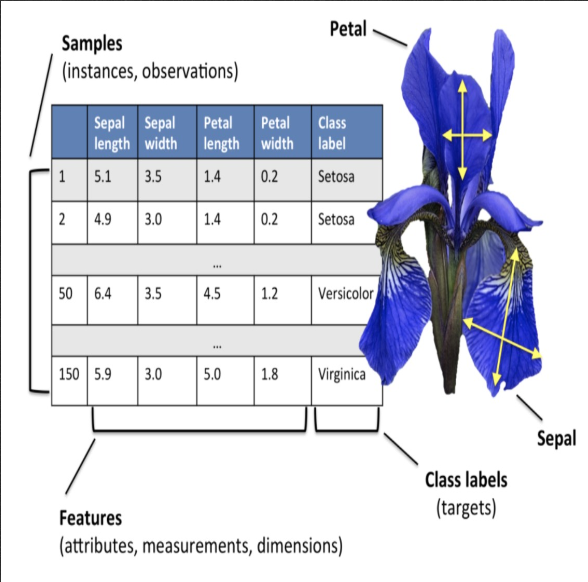

In [2]:
file_url = "https://drive.google.com/u/0/uc?id=1kior1RoKE35UVTtTqx1KOQDNF8r02X6L&export=download"
file_name = "Iris"

response = requests.get(file_url)
open(file_name, "wb").write(response.content)
iris = pd.read_csv('/content/Iris')

In [5]:
# melihat informasi dataset pada 10 baris pertama
iris.head(10)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
5,6,5.4,3.9,1.7,0.4,Iris-setosa
6,7,4.6,3.4,1.4,0.3,Iris-setosa
7,8,5.0,3.4,1.5,0.2,Iris-setosa
8,9,4.4,2.9,1.4,0.2,Iris-setosa
9,10,4.9,3.1,1.5,0.1,Iris-setosa


In [6]:
# Melihat informasi dataset
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


#SPLIT DATA

In [7]:
# menghilangkan kolom yang tidak penting
iris.drop('Id',axis=1,inplace=True)

In [8]:
# memisahkan atribut dan label
X = iris[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm' ]]
y = iris['Species']

In [9]:
# Membagi dataset menjadi data latih & data uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state= 1 )

#PENJELASAN RANDOM_STATE

Random state adalah parameter yang digunakan dalam beberapa algoritma pembelajaran mesin untuk mengontrol keacakan dalam proses Machine Learning. Ini memungkinkan kita untuk mengatur seed (benih) untuk generator angka acak yang digunakan oleh algoritma tersebut.

Ketika algoritma menggunakan random state, maka hasilnya akan tetap konsisten setiap kali algoritma tersebut dijalankan dengan nilai random state yang sama. Artinya, jika kita menjalankan algoritma dengan random state yang sama, kita akan mendapatkan hasil yang identik setiap kali. Hal ini sangat berguna saat kita ingin memastikan reproduktibilitas (reproducibility) dari eksperimen atau saat ingin membandingkan performa model secara konsisten.

In [ ]:
from sklearn.model_selection import train_test_split
import random

# Generate list of 20 random integers
my_list = [89, 68, 25, 37, 33, 3, 3]

# Split the list into 2 parts randomly without random_state
train_list, test_list = train_test_split(my_list, test_size=0.3)
print("Train List without random_state:", train_list)
print("Test List without random_state:", test_list)
print()
# Split the list into 2 parts randomly with random_state=1 
train_list, test_list = train_test_split(my_list, test_size=0.3, random_state= 1)
print("Train List with random_state:", train_list)
print("Test List with random_state:", test_list)


#lebih bagus pakai random state biar hasilnya konsisten

Train List without random_state: [25, 68, 33, 37]
Test List without random_state: [3, 3, 89]

Train List with random_state: [89, 33, 37, 3]
Test List with random_state: [3, 25, 68]


#LATIH MODEL DECISION TREE

In [10]:
# membuat model Decision Tree
tree_model = DecisionTreeClassifier (criterion = 'gini', max_depth=4)
 
# melakukan pelatihan model terhadap data
tree_model = tree_model.fit(X_train, y_train)

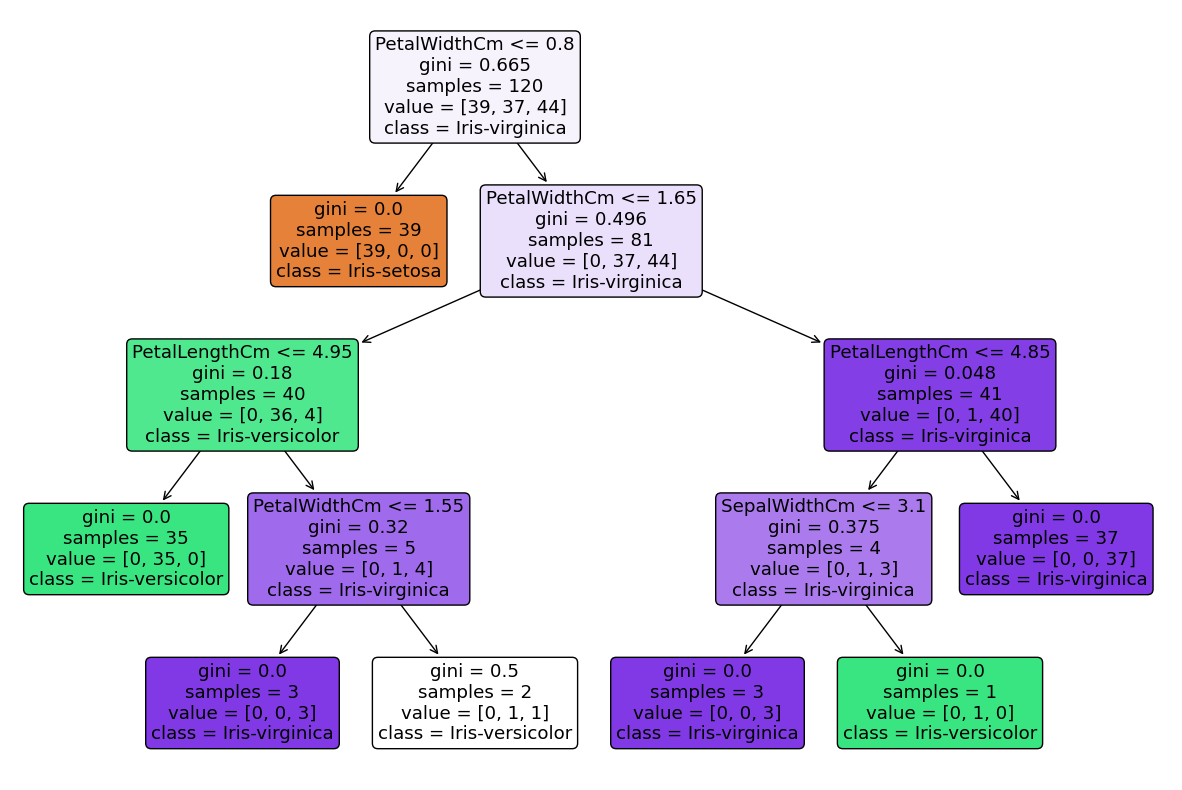

In [11]:
#visualisasi
fig, ax = plt.subplots(figsize=(15, 10))
plot_tree(tree_model, feature_names=['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm'], 
          class_names=['Iris-setosa', 'Iris-versicolor', 'Iris-virginica' ],
          rounded= True,
          filled=True)
plt.show()

In [14]:
# prediksi model dengan tree_model.predict([[SepalLength, SepalWidth, PetalLength, PetalWidth]])
print(tree_model.predict([[6.2, 3.4, 5.4, 2.3]])[0])

Iris-virginica


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [13]:
# Evaluasi Model
y_pred = tree_model.predict(X_test)

acc_secore = round(accuracy_score(y_pred, y_test), 3)

print('Accuracy: ', acc_secore)


Accuracy:  0.967
